# Support Vector Machine
Aqui vamos executar um algoritmo simples apenas para servir como base de comparação para o nosso projeto. Vamos utilizar o dataset Dataset_Alzheimers que contém as informações que vamos analisar e alimentar um classificador SVM para servir como base, uma vez que foi algoritmo com melhor desempenho testado anteriormente. Vamos fazer todos os procedimentos que executamos anteriormente: normalização dos dados pelo máximo absoluto (vamos usar este para que seja semelhante à rede neural) seleção de atributos, otimização de hiperparâmetros e validação cruzada com número de folds igual a 5

In [1]:
# Importações
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler, LabelEncoder, OneHotEncoder
from sklearn.svm import SVC
from optuna import create_study
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, KFold, train_test_split

### Importando dados

In [2]:
#Importando dados
dataframe = pd.read_csv("Dataset_Alzheimers.csv", sep=",")
dataframe = dataframe.dropna()
ATRIBUTOS = dataframe.columns.drop(["Class", "rownames", ]).tolist()
TARGET = ["Class"]
seed = 40028922
tamanho_teste = 0.1
tamanho_val = 0.1
indices = dataframe.index

### Eliminando vazamento de dados

In [3]:
df_round = dataframe.round(5)
grupo = df_round.groupby(ATRIBUTOS, sort=False)[TARGET].agg(pd.Series.mode)
df_tratado = grupo.reset_index()

C:\Users\vitor25023\AppData\Local\Temp\ipykernel_24868\417964897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tratado = grupo.reset_index()
C:\Users\vitor25023\AppData\Local\Temp\ipykernel_24868\417964897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tratado = grupo.reset_index()
C:\Users\vitor25023\AppData\Local\Temp\ipykernel_24868\417964897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

In [4]:
X = df_tratado.reindex(ATRIBUTOS, axis=1).values
y = df_tratado.reindex(TARGET, axis=1).values

### Convertendo todas as features para valores numéricos usando codificação OneHot

In [5]:
df_features = df_tratado[ATRIBUTOS]
df_target = df_tratado[TARGET]

df_features = pd.get_dummies(df_features, dtype=int, drop_first=True)
features = df_features.columns.tolist()

In [6]:
X = df_features.reindex(features, axis=1).values

In [7]:
y = df_target.values.ravel()

In [8]:

index = df_tratado.index.values


## Split treino e teste

In [9]:
#Train-test split
train_index, test_index = train_test_split(index, test_size=tamanho_teste)
train = df_features.loc[train_index]
test = df_features.loc[test_index]

train_target = df_target.loc[train_index]
test_target = df_target.loc[test_index]

X_treino = train.reindex(features, axis=1)
y_treino = train_target.reindex(TARGET, axis=1)
X_teste = test.reindex(features, axis=1)
y_teste= test_target.reindex(TARGET, axis=1)


## Convertendo os valores categóricos do target

In [10]:
from sklearn.preprocessing import LabelBinarizer
bina = LabelBinarizer()
y_treino = bina.fit_transform(y_treino).ravel()
y_teste = bina.fit_transform(y_teste).ravel()
y_val = bina.fit_transform(y).ravel()

### Fazendo normalização pelo máximo absoluto

In [11]:
norm = MaxAbsScaler()
X_treino = norm.fit_transform(X_treino, y_treino)
X_teste = norm.fit_transform(X_teste, y_teste)


### Seleção de atributos
Melhora o desempenho do modelo ao retirar colunas que não ajudam a previsão.

In [12]:
from sklearn.feature_selection import SequentialFeatureSelector
seletor = SequentialFeatureSelector(
    estimator=SVC(),
    n_features_to_select="auto",
    direction='forward',
    scoring="f1",
    cv=5,
    n_jobs = -1
)

seletor.fit(X_treino, y_treino)

,estimator,SVC()
,n_features_to_select,'auto'
,tol,None
,direction,'forward'
,scoring,'f1'
,cv,5
,n_jobs,-1
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [13]:
X_novo = seletor.transform(X_treino)
y_novo = y_treino

### Otimização de Hiperparâmetros pelo optuna

#### Funções auxiliares

In [14]:
def parametros_modelo(trial):
    parametros = {}
    parametros["C"] = trial.suggest_float("C", 0, 1)
    parametros["kernel"] = trial.suggest_categorical("kernel", ["linear", "poly", "sigmoid", "rbf"])
    
    tipo_gamma = trial.suggest_categorical("tipo gamma", ["categ", "num"])
    if tipo_gamma == "categ":
        parametros["gamma"] = trial.suggest_categorical("gamma_categ", ["auto", "scale"])
    else:
        parametros["gamma"] = trial.suggest_float("gamma_num", 1e-3, 5, log=True)
    
    if parametros["kernel"] == "poly":
        parametros["degree"] = trial.suggest_int("degree", 2, 7)
        parametros["coef0"] = trial.suggest_float("coef0", -4, 4)
    elif parametros["kernel"] == "sigmoid":
        parametros["degree"] = 3
        parametros["coef0"] = trial.suggest_float("coef0", -4, 4)
    else:
        parametros["degree"] = 3
        parametros["coef0"] = 0
    
    return parametros

In [15]:
def instancia_modelo(trial):
    parametros = parametros_modelo(trial)
    modelo = SVC(**parametros)
    return modelo

In [16]:
def objetivo(trial, X, y, num_folds):
    modelo = instancia_modelo(trial)
    metricas = cross_val_score(
        modelo,
        X,
        y,
        scoring= "f1",
        cv=num_folds
    )
    return metricas.mean()

In [17]:
NOME = "svc-alzheimer4"
objeto = create_study(
    direction="maximize",
    study_name = NOME,
    storage=f"sqlite:///{NOME}.db",
    load_if_exists=True
)

[I 2026-04-06 23:12:39,507] Using an existing study with name 'svc-alzheimer4' instead of creating a new one.


In [18]:
NUM_FOLDS = 5
def objetivo_parcial(trial):
    return objetivo(trial, X_novo, y_novo, NUM_FOLDS)

### Otimizando

In [19]:
TENTATIVAS = 100
objeto.optimize(objetivo_parcial, n_trials=TENTATIVAS)

[I 2026-04-06 23:12:39,824] Trial 100 finished with value: 0.19732854864433813 and parameters: {'C': 0.30605328895809625, 'kernel': 'poly', 'tipo gamma': 'categ', 'gamma_categ': 'auto', 'degree': 4, 'coef0': -3.7963819840162074}. Best is trial 76 with value: 0.6727268907563025.
[I 2026-04-06 23:12:40,056] Trial 101 finished with value: 0.6942533936651584 and parameters: {'C': 0.27665401162190467, 'kernel': 'poly', 'tipo gamma': 'categ', 'gamma_categ': 'scale', 'degree': 5, 'coef0': 3.2816896124524066}. Best is trial 101 with value: 0.6942533936651584.
[I 2026-04-06 23:12:40,327] Trial 102 finished with value: 0.6942533936651584 and parameters: {'C': 0.25707742043046194, 'kernel': 'poly', 'tipo gamma': 'categ', 'gamma_categ': 'scale', 'degree': 5, 'coef0': 3.3372658012591363}. Best is trial 101 with value: 0.6942533936651584.
[I 2026-04-06 23:12:40,538] Trial 103 finished with value: 0.6942533936651584 and parameters: {'C': 0.25927298253826236, 'kernel': 'poly', 'tipo gamma': 'categ', '

### Importação do estudo anterior: execute se não quiser otimizar o SVC por conta própria.

In [ ]:
from optuna import load_study

objeto = load_study(
    study_name=NOME,
    storage=f"sqlite:///{NOME}",

)
df = objeto.trials_dataframe()
df

## Executando o modelo com os hiperparâmetros selecionados

### Validação cruzada

In [20]:
parametros = objeto.best_trial.params

In [21]:

modelo = SVC(C=0.4181377394963986, kernel="poly", gamma="auto", degree=6, coef0=2.8116239632754136)

metricas = cross_val_score(
    modelo,
    X,
    y_val,
    scoring="accuracy",
    cv=5
)
print(f"O resultado da validação cruzada foi: {metricas.mean()}")

O resultado da validação cruzada foi: 0.7778833107191316


### Teste do modelo:

In [22]:
classificador = SVC()
classificador.fit(X_treino, y_treino)
y_previsto = classificador.predict(X_teste)
print(classification_report(y_teste, y_previsto))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        28
           1       0.00      0.00      0.00         6

    accuracy                           0.82        34
   macro avg       0.41      0.50      0.45        34
weighted avg       0.68      0.82      0.74        34



C:\Users\vitor25023\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vitor25023\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vitor25023\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

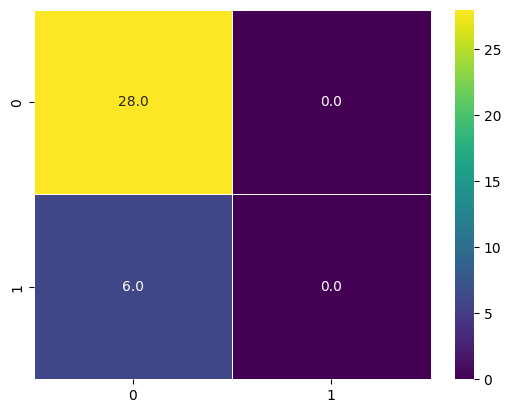

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
matriz = confusion_matrix(y_teste, y_previsto)

sns.heatmap(matriz, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
plt.title("Matriz de confusão")
plt.show()


## Conclusão:
Como resultado do nosso modelo, percebemos que sofreu-se um overfitting elevado para a classificação dos indivíduos como saudáveis (código 0), enquanto nenhum indivíduo doente foi categorizado. Isso torna o modelo insuficiente para sua função.